# Isolated test for Quantum Builders (Square Grid)
This section builds a 2D pure grid manually (without `System` or `poisson` generation). Then it immediately invokes either `kwant_solver` or `default_solver`.

In [1]:
import os
import sys
sys.path.append(os.getcwd()+"/Equantum")
import numpy as np
import matplotlib.pyplot as plt
import importlib
%matplotlib inline

from quantum_solvers.default_solver import QuantumSystem
from quantum_solvers import kwant_solver
from quantum_solvers.kpm_solver import kpm_ldos, kpm_dos


## 1. Mocking the System Class
We need to mock out the bare minimum that `QuantumSystem` and `kwant_builder` look for to function on a direct 2D list of Sites.

In [2]:
class MockSite:
    def __init__(self, idx, coords):
        self.id = idx
        self.coordinates = coords
        self.pos = coords  # kwant specifically uses .pos sometimes
        self.neighbors = {} # map of neighbor_idx -> direction/distance obj
        self.material = 'Qsystem'

class MockSystem:
    def __init__(self, L=10, W=10, a=1.0):
        self.L = L
        self.W = W
        self.lat_spacing = a
        self.t = 1.0
        self.geometry_params = {'lattice_type': 'square', 'sampling_density_function': lambda z: a}
        
        self.sites = {}  # Keep the full dict
        self.Qsites = [] # List of IDs
        
        self._build_grid()
        
    def _build_grid(self):
        grid = np.zeros((self.L, self.W), dtype=int)
        # Create Sites
        count = 0
        for x in range(self.L):
            for y in range(self.W):
                coords = [x * self.lat_spacing, y * self.lat_spacing, 0.0]
                site = MockSite(count, coords)
                self.sites[count] = site
                self.Qsites.append(count)
                grid[x, y] = count
                count += 1
                
        # Assign Neighbors (Square Grid)
        for x in range(self.L):
            for y in range(self.W):
                idx = grid[x, y]
                nhbrs = []
                if x > 0: nhbrs.append(grid[x-1, y])
                if x < self.L - 1: nhbrs.append(grid[x+1, y])
                if y > 0: nhbrs.append(grid[x, y-1])
                if y < self.W - 1: nhbrs.append(grid[x, y+1])
                
                # Fill neighbor dictionary with dummy distances
                for n in nhbrs:
                    self.sites[idx].neighbors[n] = self.lat_spacing


## 2. Test Kwant Solver
Check `kwant_solver.kwant_builder()` on the identical object.

In [3]:
print("Generating MOCK System (20x20) grid...")
mock_syst = MockSystem(L=20, W=20)
qparams = {'Ufunc': lambda site: 0.0, 'phi': 0.08}

print("Testing Kwant Solver Construction...")
kw_syst = kwant_solver.kwant_builder(mock_syst)

def Ufunc(site): return 0.0
# Setting system params as parsed by Kwant
kw_params = {'Ufunc': Ufunc, 'phi': qparams['phi']}

print("Evaluating via Kwant KPM Model...")
import kwant
spectrum_kpm = kwant.kpm.SpectralDensity(kw_syst, params=kw_params, energy_resolution=0.02)
energies_kw, dos_kw = spectrum_kpm()
print("Done.")

Generating MOCK System (20x20) grid...
Testing Kwant Solver Construction...


100%|██████████| 400/400 [00:00<00:00, 3660.84it/s]

Evaluating via Kwant KPM Model...
Done.


## 3. Test Default Solver
Ensure `default_solver` functions seamlessly on the isolated mesh.

In [4]:
print("Testing Default Solver Construction...")
#qparams = {'Ufunc': lambda site: 0.0, 'phi': 0.1}
def_solver = QuantumSystem(mock_syst, qparams=qparams)
print(f"Hamiltonian built successfully. Shape: {def_solver.H.shape}")

print("Evaluating via Default KPM Solver...")
energies_def, dos_def = def_solver.get_dos(
    qparams=None,
    i=None,
    w=energies_kw,
    M=256,
    n_random=54,
    eps=0.05,
    kernel="jackson",
)
print("Done.")

Testing Default Solver Construction...
Hamiltonian built successfully. Shape: (400, 400)
Evaluating via Default KPM Solver...
Done.


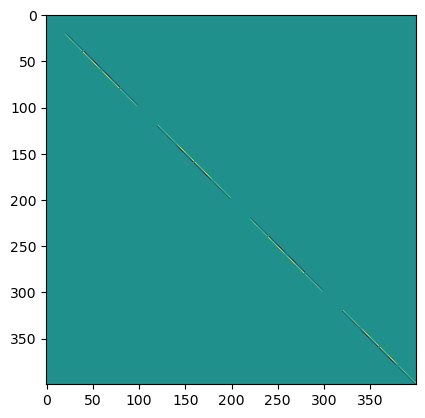

In [28]:
plt.figure()
plt.imshow(np.imag(def_solver.get_hamiltonian().toarray()))
plt.show()

## 4. Compare Spectrum by Exact Diagonalization
Extract the complete Hamiltonian matrices and diagonalize them to ensure the spectrum matches exactly.

Diagonalizing Default Hamiltonian...
Diagonalizing Kwant Hamiltonian...


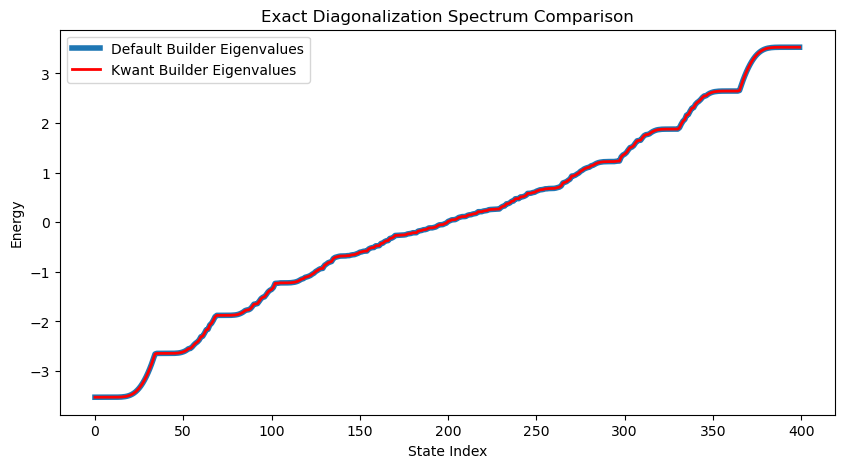

In [5]:
import scipy.linalg as sl
print("Diagonalizing Default Hamiltonian...")
H_def = def_solver.H.toarray()
eig_def = sl.eigh(H_def, eigvals_only=True)

print("Diagonalizing Kwant Hamiltonian...")
H_kw = kw_syst.hamiltonian_submatrix(params=kw_params)
eig_kw = sl.eigh(H_kw, eigvals_only=True)

plt.figure(figsize=(10, 5))
plt.plot(eig_def, label='Default Builder Eigenvalues', lw=4)
plt.plot(np.sort(eig_kw), label='Kwant Builder Eigenvalues', ls='-', c='r', lw=2)
plt.xlabel('State Index')
plt.ylabel('Energy')
plt.title('Exact Diagonalization Spectrum Comparison')
plt.legend()
plt.show()

## 5. Visual Cross-Plot (DOS)

In [6]:
H_exact = def_solver.get_hamiltonian().toarray()
evals = np.linalg.eigvalsh(H_exact)

def gaussian_broadened_dos(evals, energies, eta=0.02):
    rho = np.zeros_like(energies, dtype=float)
    pref = 1.0 / (np.sqrt(2 * np.pi) * eta)
    for ev in evals:
        rho += pref * np.exp(-0.5 * ((energies - ev) / eta)**2)
    return rho

dos_exact = gaussian_broadened_dos(evals, energies_kw, eta=0.02)

/scratch/zhaoyuha/miniconda3/envs/equant/lib/python3.9/site-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


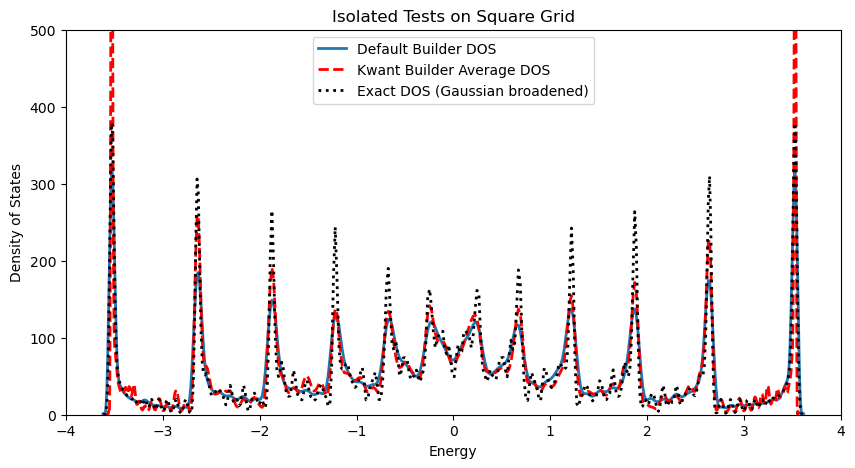

In [7]:
plt.figure(figsize=(10, 5))

plt.plot(energies_def, dos_def, label='Default Builder DOS', lw=2)
#plt.plot(energies_det, dos_det, label='Default Builder DOS from LDOS', lw=2)
plt.plot(energies_kw, dos_kw, label='Kwant Builder Average DOS', ls='--', c='r', lw=2)
plt.plot(energies_kw, dos_exact, label='Exact DOS (Gaussian broadened)', ls=':', c='k', lw=2)

plt.xlabel('Energy')
plt.ylabel('Density of States')
plt.title('Isolated Tests on Square Grid')
plt.xlim(-4,4)
plt.ylim(0,500)
plt.legend()
plt.show()

In [17]:
dos_def_n = dos_def / np.max(np.abs(dos_def))
dos_kw_n = dos_kw / np.max(np.abs(dos_kw))

print("Shape max diff:", np.max(np.abs(dos_def_n - dos_kw_n)))
print("Shape RMS diff:", np.sqrt(np.mean(np.abs(dos_def_n - dos_kw_n)**2)))

Shape max diff: 0.6752115749898132
Shape RMS diff: 0.1582445505508104


# Compare Sample LDOS with exact LDOS

## Make a Mock FSC (vanishing u)

In [ ]:
import numpy as np
from types import SimpleNamespace

def make_mock_fsc(mock_syst, def_solver):
    fsc = SimpleNamespace()

    fsc.sites = mock_syst.sites
    fsc.Qsites = list(mock_syst.Qsites)
    fsc.Qprime = list(mock_syst.Qsites)

    # map Qprime local index -> Qsites local index
    fsc.Qp_in_Q = {ii: ii for ii in range(len(fsc.Qprime))}

    # zero electrostatic potential everywhere
    n_all = len(mock_syst.sites)
    fsc.Ui = np.zeros(n_all, dtype=float)

    # only needed if you later go through qbuilder.update_ildos
    fsc.max_fill = 1.0

    return fsc

In [22]:
print("Testing Default Solver Construction...")
def_solver = QuantumSystem(mock_syst, qparams=qparams)
print(f"Hamiltonian built successfully. Shape: {def_solver.H.shape}")

mock_fsc = make_mock_fsc(mock_syst, def_solver)

Testing Default Solver Construction...
Hamiltonian built successfully. Shape: (400, 400)


AttributeError: 'types.SimpleNamespace' object has no attribute 't'

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

# Energy grid
emin, emax = def_solver.get_energy_bounds()
energies = np.linspace(emin, emax, 400)

# Exact diagonalization
H_dense = def_solver.get_hamiltonian().toarray()
evals, evecs = eigh(H_dense)

def exact_ldos(site_index, energies, eta=0.02):
    rho = np.zeros_like(energies, dtype=float)
    pref = 1.0 / (np.sqrt(2.0 * np.pi) * eta)
    weights = np.abs(evecs[site_index, :])**2
    for n, ev in enumerate(evals):
        rho += weights[n] * pref * np.exp(-0.5 * ((energies - ev) / eta)**2)
    return rho

print("Computing sampled LDOS...")
ldos_sample_data = def_solver.sample_ldos(
    mock_fsc,
    num_sample=20,
    Ncore=1,
    M=256,
    eps=0.05,
    kernel="jackson",
)
print("Done.")

sample_E = np.array([x[0] for x in ldos_sample_data])
sample_rho = np.array([x[1] for x in ldos_sample_data])

test_sites = [30,31]

for site in test_sites:
    rho_exact = exact_ldos(site, energies, eta=0.02)
    rho_sample = np.interp(energies, sample_E[site], sample_rho[site])

    rho_exact_n = rho_exact / np.max(np.abs(rho_exact))
    rho_sample_n = rho_sample / np.max(np.abs(rho_sample))

    rms_err = np.sqrt(np.mean((rho_exact_n - rho_sample_n)**2))
    print(f"Site {site}: RMS error = {rms_err:.4e}")

    plt.figure(figsize=(8, 4))
    plt.plot(energies, rho_exact_n, label=f"Exact LDOS {site}", lw=2)
    plt.plot(energies, rho_sample_n, "--", label=f"Sampled LDOS {site}", lw=2)
    plt.xlabel("Energy")
    plt.ylabel("Normalized LDOS")
    plt.legend()
    plt.tight_layout()
    plt.show()

Computing sampled LDOS...


KeyboardInterrupt: 

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from scipy.ndimage import gaussian_filter
from types import SimpleNamespace

# If not already imported
from quantum_solvers.kpm_solver import kpm_ldos


# --------------------------------------------------
# 1. Build a smooth random U background on Qsites
# --------------------------------------------------

def make_smooth_random_U(mock_syst, amplitude=0.3, sigma_sites=20.0, seed=1234):
    rng = np.random.default_rng(seed)

    L = mock_syst.L
    W = mock_syst.W

    U_grid = rng.standard_normal((L, W))
    U_grid = gaussian_filter(U_grid, sigma=sigma_sites)

    U_grid = U_grid - U_grid.mean()
    maxabs = np.max(np.abs(U_grid))
    if maxabs > 0:
        U_grid = amplitude * U_grid / maxabs

    return U_grid.ravel()


# --------------------------------------------------
# 2. Minimal mock FSC with this U background
# --------------------------------------------------

def make_mock_fsc_with_U(mock_syst, def_solver, U_qsites):
    fsc = SimpleNamespace()

    fsc.sites = mock_syst.sites
    fsc.Qsites = list(mock_syst.Qsites)
    fsc.Qprime = list(mock_syst.Qsites)
    fsc.Qp_in_Q = {ii: ii for ii in range(len(fsc.Qprime))}

    n_all = len(mock_syst.sites)
    fsc.Ui = np.zeros(n_all, dtype=float)

    for local_qidx, site_id in enumerate(fsc.Qsites):
        fsc.Ui[site_id] = U_qsites[local_qidx]

    fsc.quantum_builder = "default"
    fsc.qsystem = def_solver
    fsc.max_fill = 1.0

    return fsc


# --------------------------------------------------
# 3. Exact LDOS helper
# --------------------------------------------------

def exact_ldos_from_eigensystem(evals, evecs, site_index, energies, eta=0.03):
    rho = np.zeros_like(energies, dtype=float)
    pref = 1.0 / (np.sqrt(2.0 * np.pi) * eta)
    weights = np.abs(evecs[site_index, :]) ** 2

    for n, ev in enumerate(evals):
        rho += weights[n] * pref * np.exp(-0.5 * ((energies - ev) / eta) ** 2)

    return rho


# --------------------------------------------------
# 4. Build solver with nonzero U background
# --------------------------------------------------

print("Testing Default Solver Construction with smooth random U...")
U_qsites = make_smooth_random_U(mock_syst, amplitude=0.3, sigma_sites=2.0, seed=1234)

U_lookup = {site_id: U_qsites[i] for i, site_id in enumerate(mock_syst.Qsites)}

def Ufunc(site):
    return U_lookup[site.id]

qparams_U = {
    "phi": qparams.get("phi", 0.0),
    "Ufunc": Ufunc,
}

def_solver = QuantumSystem(mock_syst, qparams=qparams_U)
print(f"Hamiltonian built successfully. Shape: {def_solver.H.shape}")

mock_fsc = make_mock_fsc_with_U(mock_syst, def_solver, U_qsites)

# --------------------------------------------------
# 5. Energy grid from actual Hamiltonian
# --------------------------------------------------

emin, emax = def_solver.get_energy_bounds()
energies = np.linspace(emin, emax, 400)

# --------------------------------------------------
# 6. Exact diagonalization
# --------------------------------------------------

print("Diagonalizing Hamiltonian for exact LDOS...")
H_dense = def_solver.get_hamiltonian().toarray()
evals, evecs = eigh(H_dense)
print("Exact diagonalization done.")

# --------------------------------------------------
# 7. Sampled LDOS
# --------------------------------------------------

print("Computing sampled LDOS...")
ldos_sample_data, group_info = def_solver.sample_ldos(
    mock_fsc,
    num_sample=20,
    Ncore=1,
    M=256,
    eps=0.05,
    kernel="jackson",
    u_weight=2.0,
    return_groups=True,
)
print("Sampled LDOS done.")

sample_E = [np.asarray(x[0], dtype=float) for x in ldos_sample_data]
sample_rho = [np.asarray(x[1], dtype=float) for x in ldos_sample_data]

# --------------------------------------------------
# 8. Compare exact vs sampled vs direct KPM LDOS
# --------------------------------------------------

rng = np.random.default_rng(2026)
test_sites = rng.choice(def_solver.N, size=5, replace=False)

print("Comparing sampled LDOS and direct KPM LDOS to exact LDOS...")
all_rms_sample = []
all_rms_kpm = []

H_sparse = def_solver.get_hamiltonian()

for site in test_sites:
    rho_exact = exact_ldos_from_eigensystem(evals, evecs, site, energies, eta=0.03)

    # sampled LDOS
    rho_sample = np.interp(energies, sample_E[site], sample_rho[site])

    # direct KPM LDOS
    E_kpm, rho_kpm = kpm_ldos(
        H_sparse,
        site_index=site,
        energies=energies,
        num_moments=256,
        eps=0.05,
        kernel="jackson",
    )
    rho_kpm = np.asarray(rho_kpm, dtype=float)

    # normalize for shape comparison
    def normalize(arr):
        m = np.max(np.abs(arr))
        return arr / m if m > 0 else arr

    rho_exact_n = normalize(rho_exact)
    rho_sample_n = normalize(rho_sample)
    rho_kpm_n = normalize(rho_kpm)

    rms_sample = np.sqrt(np.mean((rho_exact_n - rho_sample_n) ** 2))
    rms_kpm = np.sqrt(np.mean((rho_exact_n - rho_kpm_n) ** 2))

    max_sample = np.max(np.abs(rho_exact_n - rho_sample_n))
    max_kpm = np.max(np.abs(rho_exact_n - rho_kpm_n))

    all_rms_sample.append(rms_sample)
    all_rms_kpm.append(rms_kpm)

    print(
        f"Site {site:4d}: "
        f"sample RMS = {rms_sample:.4e}, sample Max = {max_sample:.4e} | "
        f"kpm RMS = {rms_kpm:.4e}, kpm Max = {max_kpm:.4e}"
    )

    plt.figure(figsize=(8, 4))
    plt.plot(energies, rho_exact_n, label=f"Exact LDOS site {site}", lw=2)
    plt.plot(energies, rho_sample_n, "--", label="Sampled LDOS", lw=2)
    plt.plot(energies, rho_kpm_n, ":", label="Direct KPM LDOS", lw=2)
    plt.xlabel("Energy")
    plt.ylabel("Normalized LDOS")
    plt.title(f"LDOS comparison at site {site}")
    plt.legend()
    plt.tight_layout()
    plt.show()

print(f"Mean sampled RMS over tested sites: {np.mean(all_rms_sample):.4e}")
print(f"Mean direct KPM RMS over tested sites: {np.mean(all_rms_kpm):.4e}")

# --------------------------------------------------
# 9. Compare integrated density proxy
# --------------------------------------------------

print("Comparing integrated LDOS (density proxy)...")
density_errs_sample = []
density_errs_kpm = []

for site in test_sites:
    rho_exact = exact_ldos_from_eigensystem(evals, evecs, site, energies, eta=0.03)
    rho_sample = np.interp(energies, sample_E[site], sample_rho[site])

    _, rho_kpm = kpm_ldos(
        H_sparse,
        site_index=site,
        energies=energies,
        num_moments=256,
        eps=0.05,
        kernel="jackson",
    )
    rho_kpm = np.asarray(rho_kpm, dtype=float)

    n_exact = np.trapz(rho_exact, energies)
    n_sample = np.trapz(rho_sample, energies)
    n_kpm = np.trapz(rho_kpm, energies)

    density_errs_sample.append(abs(n_exact - n_sample))
    density_errs_kpm.append(abs(n_exact - n_kpm))

    print(
        f"Site {site:4d}: "
        f"|Δn_sample| = {abs(n_exact - n_sample):.4e}, "
        f"|Δn_kpm| = {abs(n_exact - n_kpm):.4e}"
    )

print(f"Mean |Δn_sample| over tested sites: {np.mean(density_errs_sample):.4e}")
print(f"Mean |Δn_kpm| over tested sites: {np.mean(density_errs_kpm):.4e}")

# --------------------------------------------------
# 10. Optional: visualize the smooth random U background
# --------------------------------------------------

plt.figure(figsize=(6, 5))
coords = np.array([mock_syst.sites[idx].coordinates[:2] for idx in mock_syst.Qsites])

# all Qsites colored by smooth background U
plt.scatter(coords[:, 0], coords[:, 1], c=U_qsites, s=30, cmap="coolwarm")
plt.colorbar(label="U background")

# highlight test sites
test_coords = coords[test_sites]
plt.scatter(
    test_coords[:, 0],
    test_coords[:, 1],
    s=120,
    facecolors="none",
    edgecolors="black",
    linewidths=2,
    label="test sites",
    zorder=3,
)

# optional: label them by site index
for site in test_sites:
    x, y = coords[site]
    plt.text(x, y, str(site), fontsize=9, ha="left", va="bottom", color="black")

plt.gca().set_aspect("equal")
plt.title("Smooth random electrostatic background on Qsites")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))

coords = group_info["coords"]
labels = group_info["labels"]
rep_sites = group_info["rep_sites"]

# color all Qprime sites by cluster label
sc = plt.scatter(
    coords[:, 0],
    coords[:, 1],
    c=labels,
    s=35,
    cmap="tab20",
)

# highlight representative site of each cluster
rep_coords = coords[rep_sites]
plt.scatter(
    rep_coords[:, 0],
    rep_coords[:, 1],
    s=160,
    facecolors="none",
    edgecolors="black",
    linewidths=2,
    label="cluster representatives",
    zorder=3,
)

# optional: highlight test sites too
test_coords = coords[test_sites]
plt.scatter(
    test_coords[:, 0],
    test_coords[:, 1],
    s=120,
    marker="x",
    c="red",
    linewidths=2,
    label="test sites",
    zorder=4,
)

# optional: annotate representative cluster ids
for k, site in enumerate(rep_sites):
    x, y = coords[site]
    plt.text(x, y, str(k), fontsize=9, ha="center", va="center", color="black")

plt.gca().set_aspect("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("KMeans grouping of Qprime sites")
plt.legend()
plt.tight_layout()
plt.show()

Testing Default Solver Construction with smooth random U...
Hamiltonian built successfully. Shape: (400, 400)
Diagonalizing Hamiltonian for exact LDOS...
Exact diagonalization done.
Computing sampled LDOS...


AttributeError: 'types.SimpleNamespace' object has no attribute 'E_global'

Generating MOCK System (100x100) grid...
Building system with smooth random U...
Hamiltonian shape: (10000, 10000)
Running exact diagonalization...
ED done in 134.007 s
Running direct KPM LDOS...
Direct KPM done in 36.891 s
Running sampled LDOS...
Sampled LDOS done in 48.585 s

=== Benchmark summary ===
ED runtime           : 134.007 s
Direct KPM runtime   : 36.891 s
Sampled LDOS runtime : 48.585 s

Direct KPM mean RMS LDOS error   : 1.5887e-01
Sampled LDOS mean RMS LDOS error : 2.5259e-01

Direct KPM mean |Δn|   : 3.0503e-01
Sampled LDOS mean |Δn| : 2.7591e-01

=== Relative speed ===
Direct KPM / ED speed ratio   : 0.2753
Sampled LDOS / ED speed ratio : 0.3626
Sampled / Direct KPM ratio    : 1.3170

=== Simple efficiency score (time × mean |Δn|) ===
Direct KPM score   : 1.1253e+01
Sampled LDOS score : 1.3405e+01


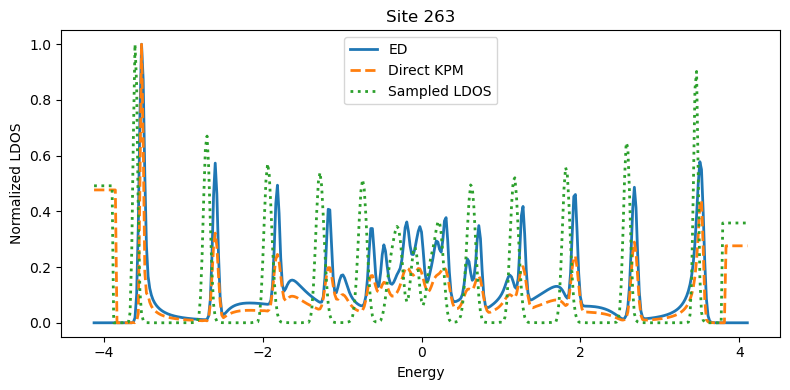

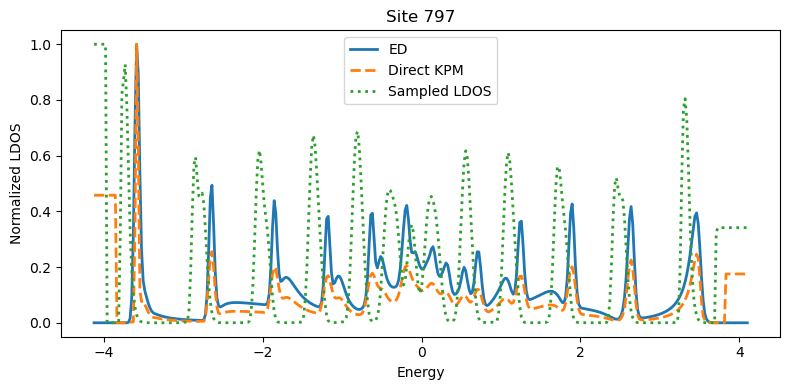

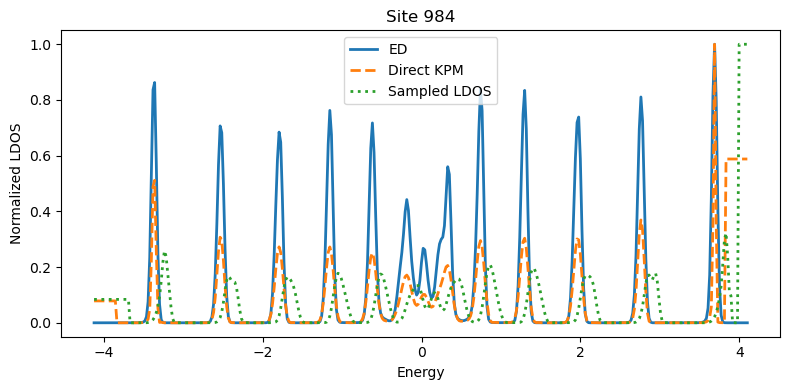

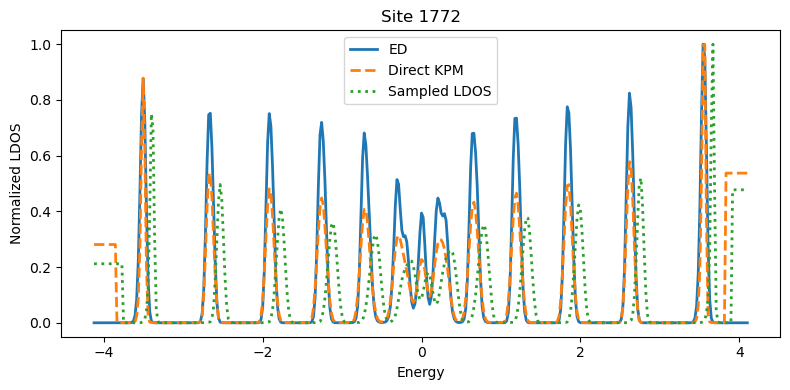

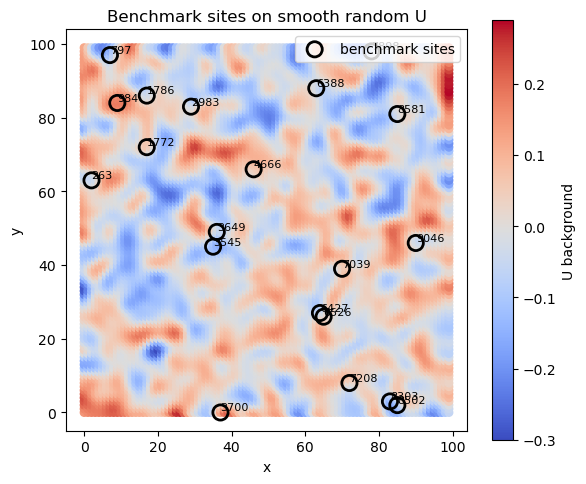

In [5]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from scipy.ndimage import gaussian_filter
from types import SimpleNamespace

from quantum_solvers.kpm_solver import kpm_ldos


# --------------------------------------------------
# Helpers
# --------------------------------------------------
print("Generating MOCK System (100x100) grid...")
mock_syst = MockSystem(L=100, W=100)
def make_smooth_random_U(mock_syst, amplitude=0.3, sigma_sites=20, seed=1234):
    rng = np.random.default_rng(seed)
    L = mock_syst.L
    W = mock_syst.W

    U_grid = rng.standard_normal((L, W))
    U_grid = gaussian_filter(U_grid, sigma=sigma_sites)
    U_grid = U_grid - U_grid.mean()

    maxabs = np.max(np.abs(U_grid))
    if maxabs > 0:
        U_grid = amplitude * U_grid / maxabs

    return U_grid.ravel()


def make_mock_fsc_with_U(mock_syst, def_solver, U_qsites):
    fsc = SimpleNamespace()
    fsc.sites = mock_syst.sites
    fsc.Qsites = list(mock_syst.Qsites)
    fsc.Qprime = list(mock_syst.Qsites)
    fsc.Qp_in_Q = {ii: ii for ii in range(len(fsc.Qprime))}

    n_all = len(mock_syst.sites)
    fsc.Ui = np.zeros(n_all, dtype=float)
    for local_qidx, site_id in enumerate(fsc.Qsites):
        fsc.Ui[site_id] = U_qsites[local_qidx]

    fsc.quantum_builder = "default"
    fsc.qsystem = def_solver
    fsc.max_fill = 1.0
    return fsc


def exact_ldos_from_eigensystem(evals, evecs, site_index, energies, eta=0.03):
    rho = np.zeros_like(energies, dtype=float)
    pref = 1.0 / (np.sqrt(2.0 * np.pi) * eta)
    weights = np.abs(evecs[site_index, :]) ** 2

    for n, ev in enumerate(evals):
        rho += weights[n] * pref * np.exp(-0.5 * ((energies - ev) / eta) ** 2)

    return rho


def normalize(arr):
    arr = np.asarray(arr, dtype=float)
    m = np.max(np.abs(arr))
    return arr / m if m > 0 else arr


# --------------------------------------------------
# Build system with smooth random background U
# --------------------------------------------------

print("Building system with smooth random U...")
U_qsites = make_smooth_random_U(mock_syst, amplitude=0.3, sigma_sites=2.0, seed=1234)

U_lookup = {site_id: U_qsites[i] for i, site_id in enumerate(mock_syst.Qsites)}

def Ufunc(site):
    return U_lookup[site.id]

qparams_U = {
    "phi": qparams.get("phi", 0.0),
    "Ufunc": Ufunc,
}

def_solver = QuantumSystem(mock_syst, qparams=qparams_U)
mock_fsc = make_mock_fsc_with_U(mock_syst, def_solver, U_qsites)

emin, emax = def_solver.get_energy_bounds()
energies = np.linspace(emin, emax, 400)

H_sparse = def_solver.get_hamiltonian()
H_dense = H_sparse.toarray()

print(f"Hamiltonian shape: {H_dense.shape}")


# --------------------------------------------------
# Choose benchmark sites
# --------------------------------------------------

rng = np.random.default_rng(2026)
n_test_sites = 20
test_sites = np.sort(rng.choice(def_solver.N, size=n_test_sites, replace=False))


# --------------------------------------------------
# 1. Exact diagonalization reference
# --------------------------------------------------

print("Running exact diagonalization...")
t0 = time.perf_counter()
evals, evecs = eigh(H_dense)
t_ed = time.perf_counter() - t0
print(f"ED done in {t_ed:.3f} s")

ldos_ed = {}
for site in test_sites:
    ldos_ed[site] = exact_ldos_from_eigensystem(evals, evecs, site, energies, eta=0.03)


# --------------------------------------------------
# 2. Direct KPM LDOS on benchmark sites
# --------------------------------------------------

print("Running direct KPM LDOS...")
t0 = time.perf_counter()
ldos_direct = {}

for site in test_sites:
    E_kpm, rho_kpm = kpm_ldos(
        H_sparse,
        site_index=site,
        energies=energies,
        num_moments=256,
        eps=0.05,
        kernel="jackson",
    )
    ldos_direct[site] = np.asarray(rho_kpm, dtype=float)

t_direct = time.perf_counter() - t0
print(f"Direct KPM done in {t_direct:.3f} s")


# --------------------------------------------------
# 3. Sampled LDOS over full system
#    includes KMeans + representative KPM cost
# --------------------------------------------------

print("Running sampled LDOS...")
t0 = time.perf_counter()
ldos_sample_data = def_solver.sample_ldos(
    mock_fsc,
    num_sample=20,
    Ncore=1,
    M=256,
    eps=0.05,
    kernel="jackson",
    u_weight=2.0,
)
t_sample = time.perf_counter() - t0
print(f"Sampled LDOS done in {t_sample:.3f} s")

sample_E = [np.asarray(x[0], dtype=float) for x in ldos_sample_data]
sample_rho = [np.asarray(x[1], dtype=float) for x in ldos_sample_data]


# --------------------------------------------------
# Error analysis
# --------------------------------------------------

rms_direct = []
rms_sample = []
density_direct = []
density_sample = []

for site in test_sites:
    rho_ref = ldos_ed[site]
    rho_direct = ldos_direct[site]
    rho_sample = np.interp(energies, sample_E[site], sample_rho[site])

    # normalized LDOS shape error
    rms_direct.append(
        np.sqrt(np.mean((normalize(rho_ref) - normalize(rho_direct)) ** 2))
    )
    rms_sample.append(
        np.sqrt(np.mean((normalize(rho_ref) - normalize(rho_sample)) ** 2))
    )

    # integrated density proxy
    n_ref = np.trapz(rho_ref, energies)
    n_direct = np.trapz(rho_direct, energies)
    n_sample = np.trapz(rho_sample, energies)

    density_direct.append(abs(n_ref - n_direct))
    density_sample.append(abs(n_ref - n_sample))


# --------------------------------------------------
# Summary table
# --------------------------------------------------

print("\n=== Benchmark summary ===")
print(f"ED runtime           : {t_ed:.3f} s")
print(f"Direct KPM runtime   : {t_direct:.3f} s")
print(f"Sampled LDOS runtime : {t_sample:.3f} s")
print()
print(f"Direct KPM mean RMS LDOS error   : {np.mean(rms_direct):.4e}")
print(f"Sampled LDOS mean RMS LDOS error : {np.mean(rms_sample):.4e}")
print()
print(f"Direct KPM mean |Δn|   : {np.mean(density_direct):.4e}")
print(f"Sampled LDOS mean |Δn| : {np.mean(density_sample):.4e}")


# --------------------------------------------------
# Speedup metrics
# --------------------------------------------------

print("\n=== Relative speed ===")
print(f"Direct KPM / ED speed ratio   : {t_direct / t_ed:.4f}")
print(f"Sampled LDOS / ED speed ratio : {t_sample / t_ed:.4f}")
print(f"Sampled / Direct KPM ratio    : {t_sample / t_direct:.4f}")


# --------------------------------------------------
# Efficiency score: time × mean density error
# lower is better
# --------------------------------------------------

score_direct = t_direct * np.mean(density_direct)
score_sample = t_sample * np.mean(density_sample)

print("\n=== Simple efficiency score (time × mean |Δn|) ===")
print(f"Direct KPM score   : {score_direct:.4e}")
print(f"Sampled LDOS score : {score_sample:.4e}")


# --------------------------------------------------
# Plot example sites
# --------------------------------------------------

for site in test_sites[:4]:
    rho_ref = ldos_ed[site]
    rho_direct = ldos_direct[site]
    rho_sample = np.interp(energies, sample_E[site], sample_rho[site])

    plt.figure(figsize=(8, 4))
    plt.plot(energies, normalize(rho_ref), label="ED", lw=2)
    plt.plot(energies, normalize(rho_direct), "--", label="Direct KPM", lw=2)
    plt.plot(energies, normalize(rho_sample), ":", label="Sampled LDOS", lw=2)
    plt.xlabel("Energy")
    plt.ylabel("Normalized LDOS")
    plt.title(f"Site {site}")
    plt.legend()
    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# Plot benchmark sites on top of U landscape
# --------------------------------------------------

coords = np.array([mock_syst.sites[idx].coordinates[:2] for idx in mock_syst.Qsites])

plt.figure(figsize=(6, 5))
plt.scatter(coords[:, 0], coords[:, 1], c=U_qsites, s=30, cmap="coolwarm")
plt.colorbar(label="U background")

test_coords = coords[test_sites]
plt.scatter(
    test_coords[:, 0],
    test_coords[:, 1],
    s=120,
    facecolors="none",
    edgecolors="black",
    linewidths=2,
    label="benchmark sites",
    zorder=3,
)

for site in test_sites:
    x, y = coords[site]
    plt.text(x, y, str(site), fontsize=8, ha="left", va="bottom", color="black")

plt.gca().set_aspect("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Benchmark sites on smooth random U")
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
import time
import kwant
import numpy as np
import matplotlib.pyplot as plt

from quantum_solvers import kwant_solver

print("Building Kwant system...")
kw_syst = kwant_solver.kwant_builder(mock_syst)

kw_params = {
    "phi": qparams_U["phi"],
    "Ufunc": Ufunc,   # same Ufunc used in default solver
}

print("Kwant system built.")

Building Kwant system...


100%|██████████| 10000/10000 [01:03<00:00, 157.52it/s]


Kwant system built.


In [7]:
# default solver coordinates in Qsite order
coords_def = np.array([mock_syst.sites[idx].coordinates[:2] for idx in mock_syst.Qsites])

# kwant finalized coordinates
coords_kw = np.array([site.pos for site in kw_syst.sites])

# map: default local q-index -> kwant finalized site index
default_to_kwant = {}

for i, c in enumerate(coords_def):
    dists = np.linalg.norm(coords_kw - c, axis=1)
    j = np.argmin(dists)
    if dists[j] > 1e-8:
        raise RuntimeError(f"Could not match default site {i} to Kwant site.")
    default_to_kwant[i] = j

print("Default-to-Kwant site mapping built.")

Default-to-Kwant site mapping built.


In [13]:
def kwant_ldos_for_site(kw_syst, kw_site_index, energies, params, num_moments=256):
    target_site = kw_syst.sites[kw_site_index]
    op = kwant.operator.Density(kw_syst, where=[target_site])

    spec = kwant.kpm.SpectralDensity(
        kw_syst,
        operator=op,
        params=params,
        num_moments=num_moments,
    )

    E, rho = spec()
    return np.asarray(E, dtype=float), np.asarray(rho, dtype=float)

In [20]:
print("Running Kwant KPM LDOS on test sites...")
t0 = time.perf_counter()

kwant_ldos = {}

for site in test_sites:
    kw_site = default_to_kwant[site]
    E_kw, rho_kw = kwant_ldos_for_site(
        kw_syst,
        kw_site,
        energies,
        kw_params,
    )
    kwant_ldos[site] = rho_kw

t_kw_ldos = time.perf_counter() - t0
print(f"Kwant KPM LDOS on test sites done in {t_kw_ldos:.3f} s")

Running Kwant KPM LDOS on test sites...


/tmp/ipykernel_1175500/2914308210.py:13: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(E, dtype=float), np.asarray(rho, dtype=float)


Kwant KPM LDOS on test sites done in 159.703 s


Site  263: RMS(direct,ED)=1.2632e-01 | RMS(sample,ED)=1.9853e-01 | RMS(kwant,ED)=2.0767e-01


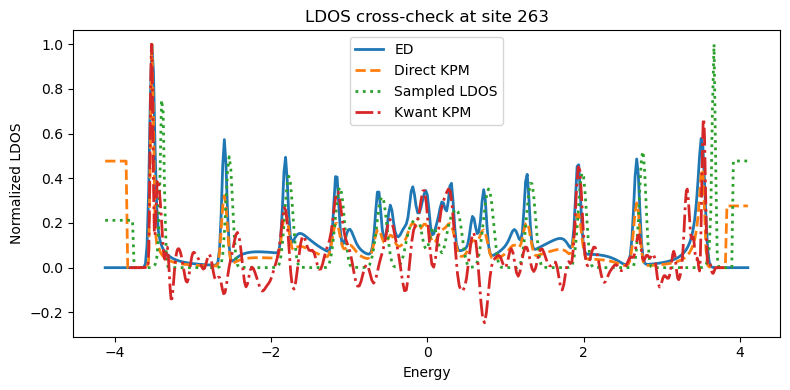

Site  797: RMS(direct,ED)=1.2006e-01 | RMS(sample,ED)=2.0126e-01 | RMS(kwant,ED)=2.3829e-01


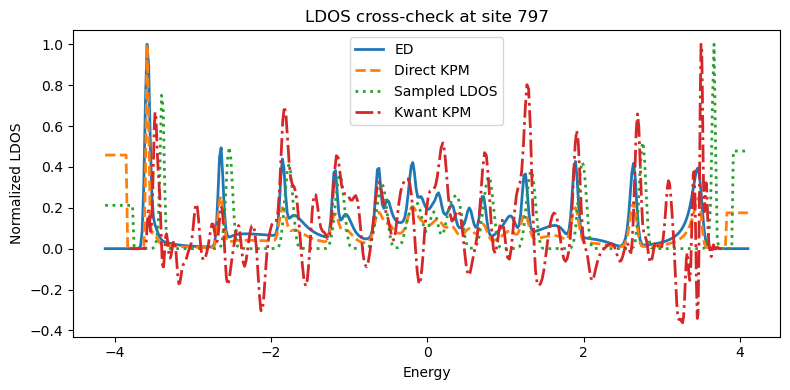

Site  984: RMS(direct,ED)=1.7719e-01 | RMS(sample,ED)=1.5858e-01 | RMS(kwant,ED)=2.6104e-01


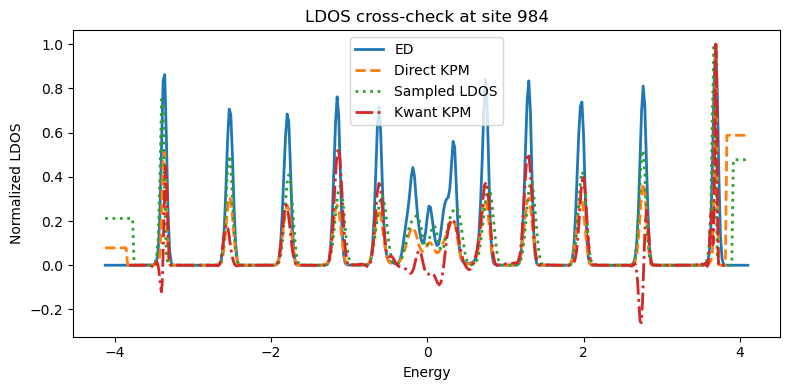

Site 1772: RMS(direct,ED)=1.3986e-01 | RMS(sample,ED)=2.9042e-01 | RMS(kwant,ED)=2.9939e-01


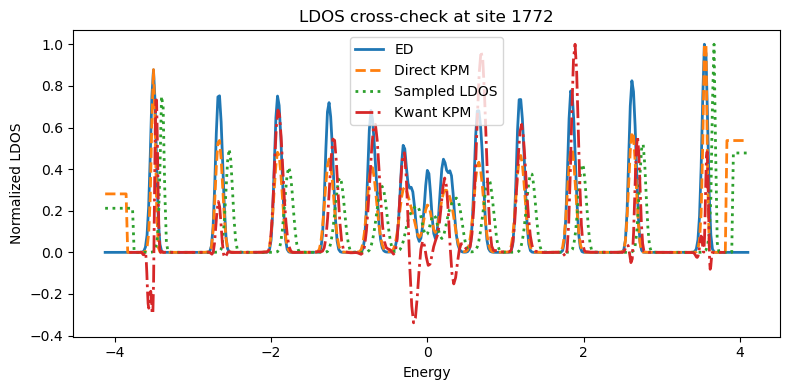

Site 1786: RMS(direct,ED)=1.4747e-01 | RMS(sample,ED)=2.7586e-01 | RMS(kwant,ED)=2.9262e-01


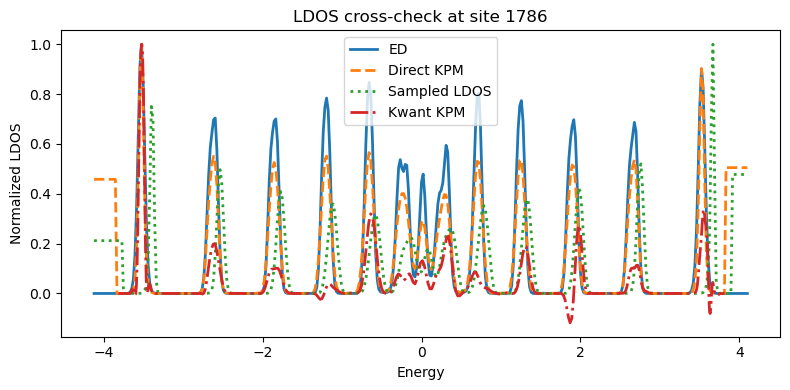

Site 2983: RMS(direct,ED)=1.3878e-01 | RMS(sample,ED)=3.0500e-01 | RMS(kwant,ED)=2.9057e-01


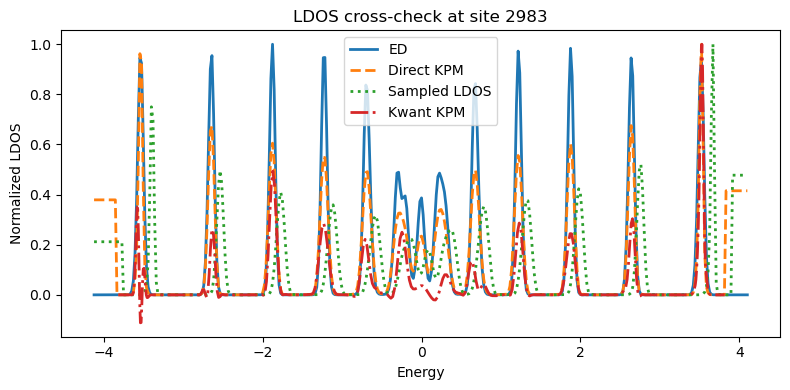

Site 3545: RMS(direct,ED)=2.2895e-01 | RMS(sample,ED)=3.1927e-01 | RMS(kwant,ED)=2.9610e-01


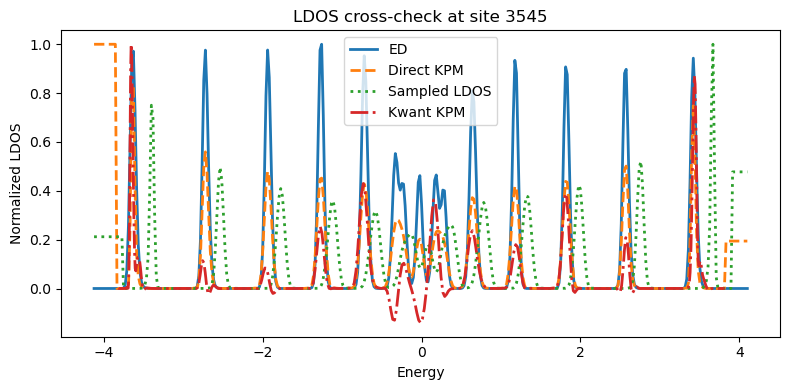

Site 3649: RMS(direct,ED)=1.7199e-01 | RMS(sample,ED)=3.2594e-01 | RMS(kwant,ED)=3.3954e-01


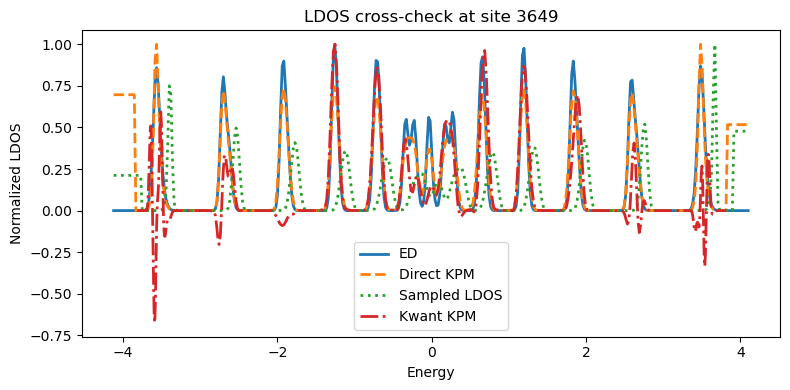

Site 3700: RMS(direct,ED)=1.6661e-01 | RMS(sample,ED)=4.2273e-01 | RMS(kwant,ED)=4.3516e-01


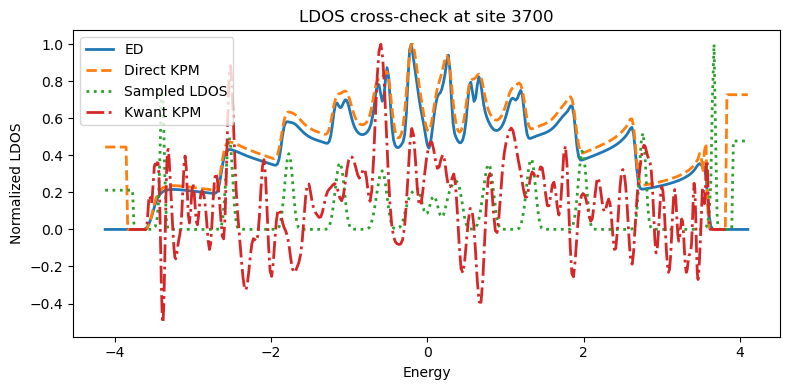

Site 4666: RMS(direct,ED)=1.4379e-01 | RMS(sample,ED)=2.2838e-01 | RMS(kwant,ED)=2.6601e-01


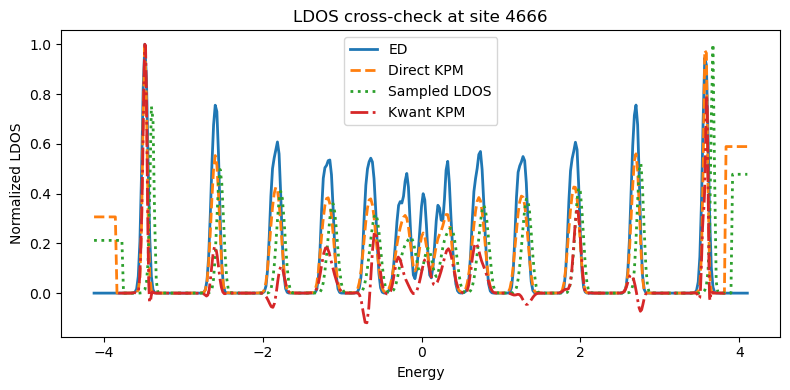

Site 6388: RMS(direct,ED)=1.4379e-01 | RMS(sample,ED)=3.1380e-01 | RMS(kwant,ED)=3.0452e-01


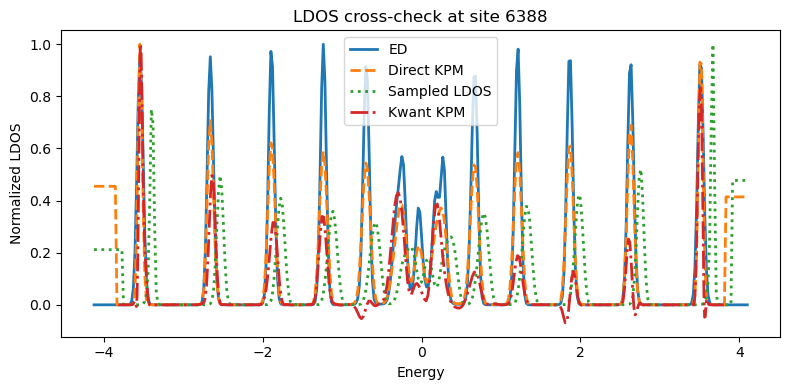

Site 6427: RMS(direct,ED)=1.5356e-01 | RMS(sample,ED)=2.9159e-01 | RMS(kwant,ED)=3.0175e-01


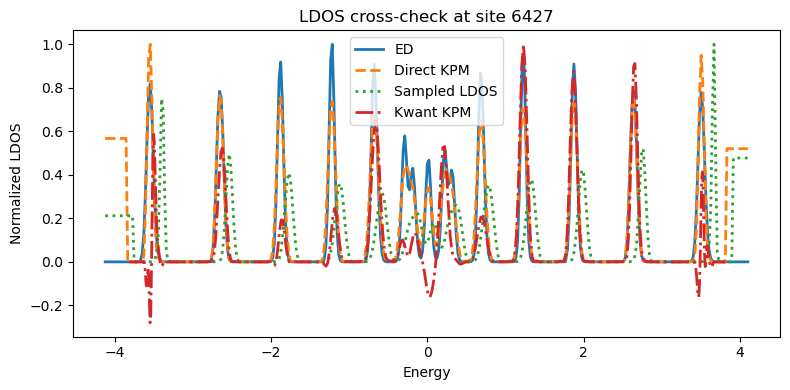

Site 6526: RMS(direct,ED)=1.5604e-01 | RMS(sample,ED)=2.8855e-01 | RMS(kwant,ED)=3.0933e-01


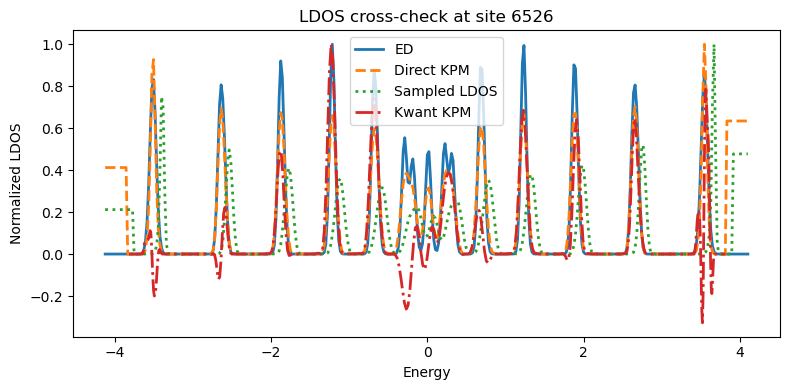

Site 7039: RMS(direct,ED)=1.4176e-01 | RMS(sample,ED)=2.6439e-01 | RMS(kwant,ED)=2.8950e-01


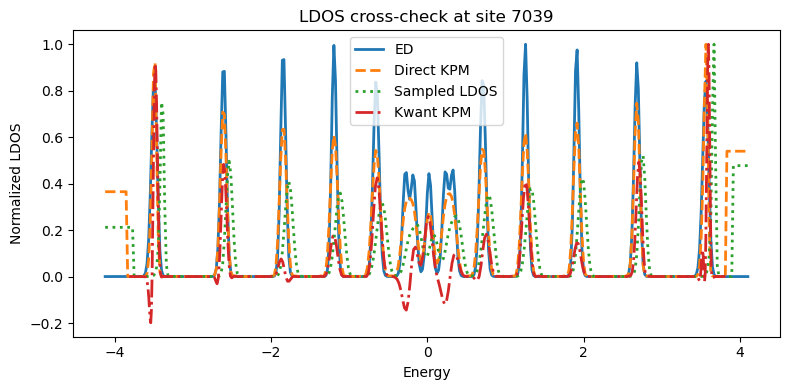

Site 7208: RMS(direct,ED)=1.5116e-01 | RMS(sample,ED)=2.7633e-01 | RMS(kwant,ED)=2.8925e-01


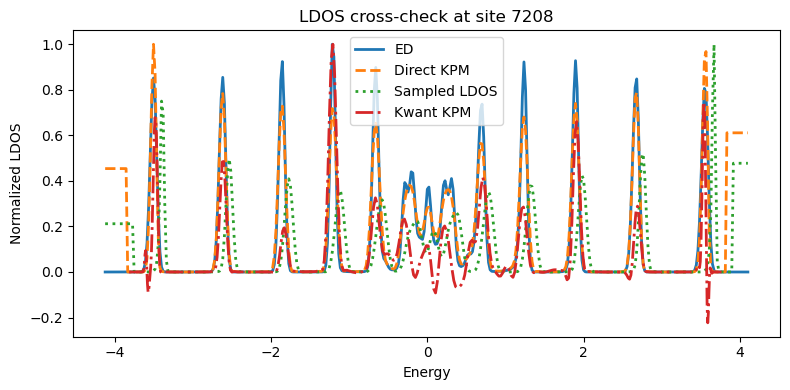

Site 7898: RMS(direct,ED)=2.2041e-01 | RMS(sample,ED)=3.4290e-01 | RMS(kwant,ED)=3.4404e-01


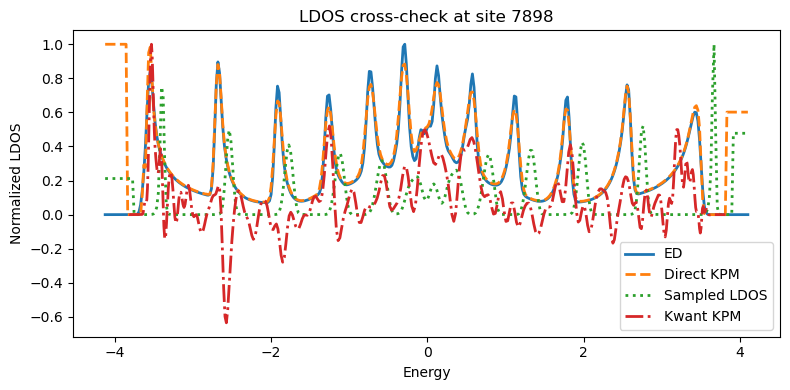

Site 8303: RMS(direct,ED)=1.5875e-01 | RMS(sample,ED)=2.2892e-01 | RMS(kwant,ED)=2.0432e-01


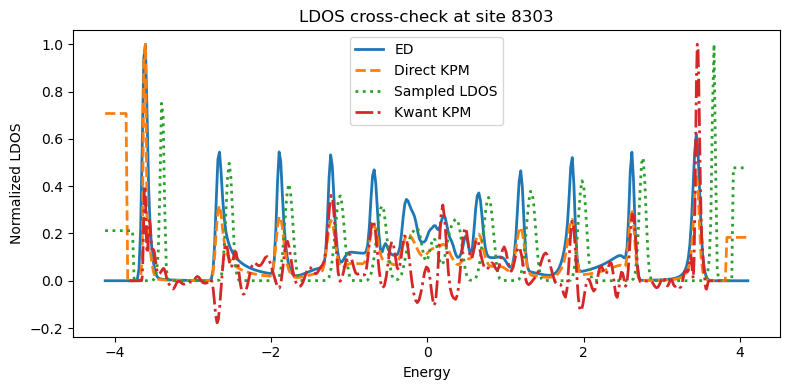

Site 8502: RMS(direct,ED)=1.8266e-01 | RMS(sample,ED)=2.4020e-01 | RMS(kwant,ED)=2.3819e-01


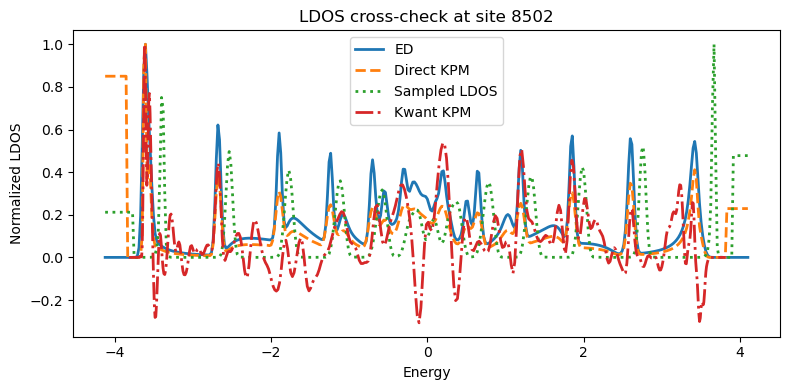

Site 8581: RMS(direct,ED)=1.5500e-01 | RMS(sample,ED)=3.2548e-01 | RMS(kwant,ED)=2.9663e-01


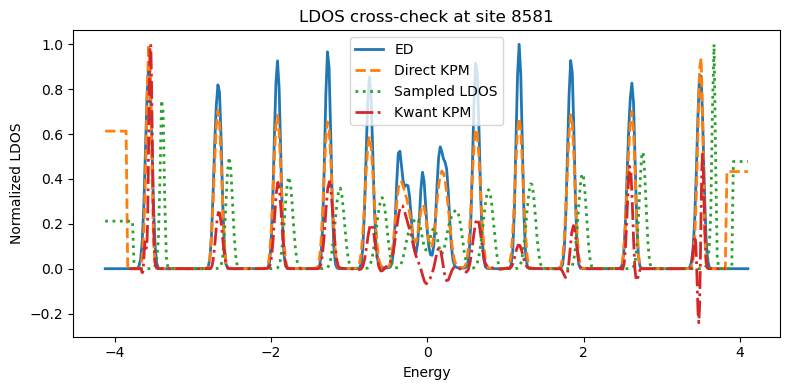

Site 9046: RMS(direct,ED)=1.5332e-01 | RMS(sample,ED)=2.3893e-01 | RMS(kwant,ED)=3.0951e-01


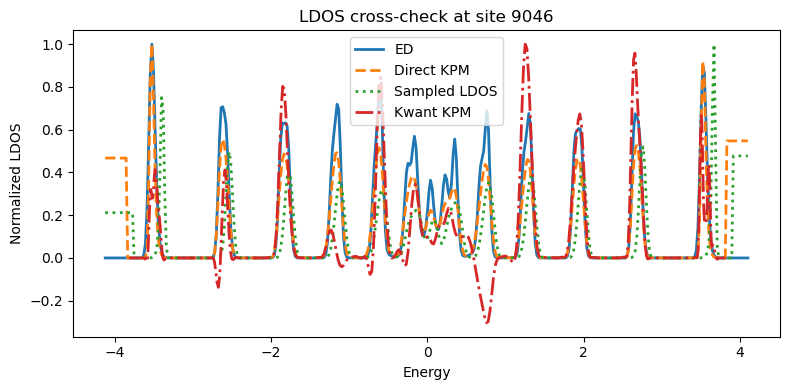

Mean Kwant LDOS RMS vs ED: 2.9067e-01


In [21]:
rms_kwant = []

for site in test_sites:
    rho_ed = ldos_ed[site]
    rho_direct = ldos_direct[site]
    rho_kw = kwant_ldos[site]

    rms_kw = np.sqrt(np.mean((normalize(rho_ed) - normalize(rho_kw)) ** 2))
    rms_kwant.append(rms_kw)

    print(
        f"Site {site:4d}: "
        f"RMS(direct,ED)={np.sqrt(np.mean((normalize(rho_ed)-normalize(rho_direct))**2)):.4e} | "
        f"RMS(sample,ED)={np.sqrt(np.mean((normalize(rho_ed)-normalize(rho_sample))**2)):.4e} | "
        f"RMS(kwant,ED)={rms_kw:.4e}"
    )

    plt.figure(figsize=(8, 4))
    plt.plot(energies, normalize(rho_ed), label="ED", lw=2)
    plt.plot(energies, normalize(rho_direct), "--", label="Direct KPM", lw=2)
    plt.plot(energies, normalize(rho_sample), ":", label="Sampled LDOS", lw=2)
    plt.plot(E_kw, normalize(rho_kw), "-.", label="Kwant KPM", lw=2)
    plt.xlabel("Energy")
    plt.ylabel("Normalized LDOS")
    plt.title(f"LDOS cross-check at site {site}")
    plt.legend()
    plt.tight_layout()
    plt.show()

print(f"Mean Kwant LDOS RMS vs ED: {np.mean(rms_kwant):.4e}")

In [ ]:
density_kwant = []

for site in test_sites:
    rho_ed = ldos_ed_all[site]
    rho_kw = kwant_ldos[site]

    n_ed = np.trapz(rho_ed, energies)
    n_kw = np.trapz(rho_kw, energies)

    density_kwant.append(abs(n_ed - n_kw))

print(f"Mean Kwant |Δn| vs ED: {np.mean(density_kwant):.4e}")

In [ ]:
print("\n=== Kwant cross-check summary ===")
print(f"Kwant total DOS runtime     : {t_kw_dos:.3f} s")
print(f"Kwant test-site LDOS runtime: {t_kw_ldos:.3f} s")
print(f"Mean Kwant LDOS RMS vs ED   : {np.mean(rms_kwant):.4e}")
print(f"Mean Kwant |Δn| vs ED       : {np.mean(density_kwant):.4e}")